In [1]:
import torch
import torch.nn as nn
import torch.optim as optim
import torchvision
import torchvision.transforms as transforms
from torch.utils.data import DataLoader
import torchvision.models as models

from sklearn.metrics import classification_report, confusion_matrix
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(device)

cuda


In [2]:
transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(
        mean=[0.485, 0.456, 0.406],
        std=[0.229, 0.224, 0.225]
    )
])

## **Dataset 1 CIFAR**

Dataset 1

Train:

Custom CNN

ResNet18

EfficientNet-B0

Loss: CrossEntropy

Optimizer: Adam

Epochs: 5

In [4]:
train_dataset = torchvision.datasets.CIFAR10(
    root='./data',
    train=True,
    download=True,
    transform=transform
)

test_dataset = torchvision.datasets.CIFAR10(
    root='./data',
    train=False,
    download=True,
    transform=transform
)

train_loader = DataLoader(train_dataset, batch_size=64, shuffle=True)
test_loader = DataLoader(test_dataset, batch_size=64, shuffle=False)

num_classes = 10

100%|██████████| 170M/170M [00:01<00:00, 99.6MB/s] 


In [5]:
class CustomCNN(nn.Module):
    def __init__(self, num_classes):
        super(CustomCNN, self).__init__()

        self.features = nn.Sequential(
            nn.Conv2d(3, 32, 3, padding=1),
            nn.BatchNorm2d(32),
            nn.ReLU(),
            nn.MaxPool2d(2),

            nn.Conv2d(32, 64, 3, padding=1),
            nn.BatchNorm2d(64),
            nn.ReLU(),
            nn.MaxPool2d(2),

            nn.Conv2d(64, 128, 3, padding=1),
            nn.BatchNorm2d(128),
            nn.ReLU(),
            nn.MaxPool2d(2)
        )

        self.classifier = nn.Sequential(
            nn.Flatten(),
            nn.Linear(128 * 28 * 28, 256),
            nn.ReLU(),
            nn.Dropout(0.5),
            nn.Linear(256, num_classes)
        )

    def forward(self, x):
        x = self.features(x)
        x = self.classifier(x)
        return x

In [6]:
resnet = models.resnet18(weights="IMAGENET1K_V1")
resnet.fc = nn.Linear(resnet.fc.in_features, num_classes)
resnet = resnet.to(device)

Downloading: "https://download.pytorch.org/models/resnet18-f37072fd.pth" to /root/.cache/torch/hub/checkpoints/resnet18-f37072fd.pth


100%|██████████| 44.7M/44.7M [00:00<00:00, 165MB/s]


In [7]:
efficientnet = models.efficientnet_b0(weights="IMAGENET1K_V1")
efficientnet.classifier[1] = nn.Linear(
    efficientnet.classifier[1].in_features,
    num_classes
)
efficientnet = efficientnet.to(device)

Downloading: "https://download.pytorch.org/models/efficientnet_b0_rwightman-7f5810bc.pth" to /root/.cache/torch/hub/checkpoints/efficientnet_b0_rwightman-7f5810bc.pth


100%|██████████| 20.5M/20.5M [00:00<00:00, 137MB/s] 


In [8]:
custom_model = CustomCNN(num_classes).to(device)

In [9]:
def train_model(model, train_loader, test_loader, epochs=5):
    
    criterion = nn.CrossEntropyLoss()
    optimizer = optim.Adam(model.parameters(), lr=0.001)

    for epoch in range(epochs):
        model.train()
        running_loss = 0.0
        
        for images, labels in train_loader:
            images, labels = images.to(device), labels.to(device)
            
            optimizer.zero_grad()
            outputs = model(images)
            loss = criterion(outputs, labels)
            loss.backward()
            optimizer.step()
            
            running_loss += loss.item()

        print(f"Epoch [{epoch+1}/{epochs}], Loss: {running_loss/len(train_loader):.4f}")

    print("Training Complete")

In [10]:
def evaluate_model(model, test_loader):
    
    model.eval()
    all_preds = []
    all_labels = []

    correct = 0
    total = 0

    with torch.no_grad():
        for images, labels in test_loader:
            images, labels = images.to(device), labels.to(device)
            
            outputs = model(images)
            _, preds = torch.max(outputs, 1)
            
            correct += (preds == labels).sum().item()
            total += labels.size(0)

            all_preds.extend(preds.cpu().numpy())
            all_labels.extend(labels.cpu().numpy())

    accuracy = correct / total
    print(f"Accuracy: {accuracy:.4f}")

    print("\nClassification Report:")
    print(classification_report(all_labels, all_preds))

    cm = confusion_matrix(all_labels, all_preds)
    plt.figure(figsize=(8,6))
    sns.heatmap(cm, annot=False, cmap="Blues")
    plt.title("Confusion Matrix")
    plt.show()

    return accuracy

Epoch [1/5], Loss: 2.4095
Epoch [2/5], Loss: 2.1244
Epoch [3/5], Loss: 2.0702
Epoch [4/5], Loss: 2.0367
Epoch [5/5], Loss: 2.0020
Training Complete
Accuracy: 0.2796

Classification Report:
              precision    recall  f1-score   support

           0       0.54      0.35      0.42      1000
           1       0.41      0.85      0.55      1000
           2       0.18      0.04      0.06      1000
           3       0.17      0.04      0.07      1000
           4       0.00      0.00      0.00      1000
           5       0.17      0.87      0.28      1000
           6       0.19      0.04      0.07      1000
           7       0.09      0.02      0.03      1000
           8       0.54      0.53      0.53      1000
           9       0.22      0.07      0.10      1000

    accuracy                           0.28     10000
   macro avg       0.25      0.28      0.21     10000
weighted avg       0.25      0.28      0.21     10000



/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


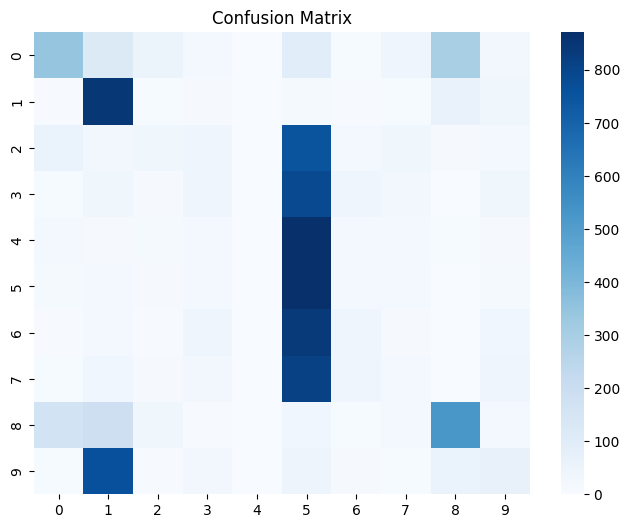

0.2796

In [11]:
train_model(custom_model, train_loader, test_loader, epochs=5)
evaluate_model(custom_model, test_loader)

Epoch [1/5], Loss: 0.5533
Epoch [2/5], Loss: 0.3174
Epoch [3/5], Loss: 0.2255
Epoch [4/5], Loss: 0.1579
Epoch [5/5], Loss: 0.1277
Training Complete
Accuracy: 0.8840

Classification Report:
              precision    recall  f1-score   support

           0       0.91      0.86      0.89      1000
           1       0.94      0.97      0.95      1000
           2       0.81      0.91      0.86      1000
           3       0.96      0.54      0.69      1000
           4       0.91      0.91      0.91      1000
           5       0.71      0.93      0.80      1000
           6       0.90      0.94      0.92      1000
           7       0.91      0.92      0.92      1000
           8       0.98      0.89      0.93      1000
           9       0.92      0.96      0.94      1000

    accuracy                           0.88     10000
   macro avg       0.89      0.88      0.88     10000
weighted avg       0.89      0.88      0.88     10000



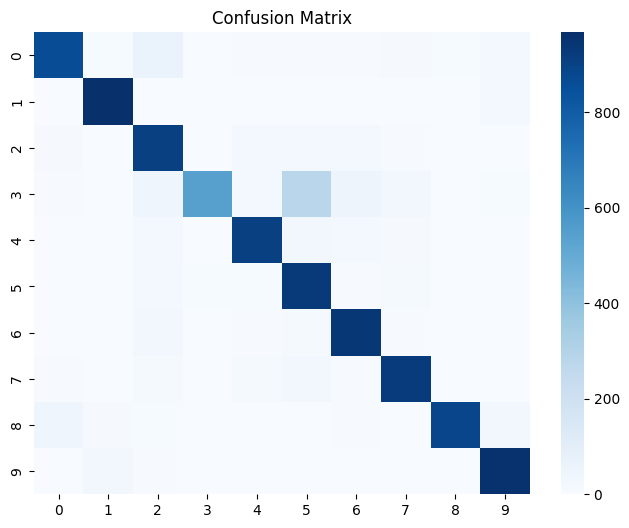

0.884

In [12]:
train_model(resnet, train_loader, test_loader, epochs=5)
evaluate_model(resnet, test_loader)

Epoch [1/5], Loss: 0.3788
Epoch [2/5], Loss: 0.2088
Epoch [3/5], Loss: 0.1550
Epoch [4/5], Loss: 0.1285
Epoch [5/5], Loss: 0.1103
Training Complete
Accuracy: 0.9389

Classification Report:
              precision    recall  f1-score   support

           0       0.90      0.97      0.93      1000
           1       0.97      0.97      0.97      1000
           2       0.96      0.89      0.92      1000
           3       0.87      0.90      0.89      1000
           4       0.93      0.94      0.94      1000
           5       0.90      0.90      0.90      1000
           6       0.94      0.97      0.96      1000
           7       0.99      0.94      0.96      1000
           8       0.97      0.95      0.96      1000
           9       0.97      0.95      0.96      1000

    accuracy                           0.94     10000
   macro avg       0.94      0.94      0.94     10000
weighted avg       0.94      0.94      0.94     10000



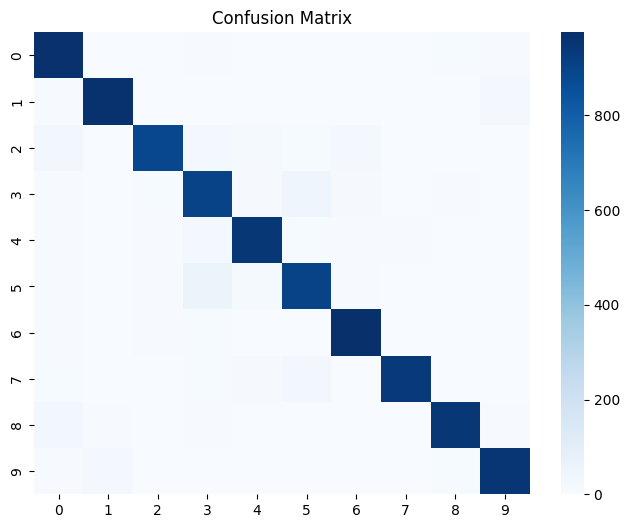

0.9389

In [13]:
train_model(efficientnet, train_loader, test_loader, epochs=5)
evaluate_model(efficientnet, test_loader)

In [14]:
from sklearn.metrics import precision_score, recall_score, f1_score

def evaluate_model(model, test_loader):
    model.eval()
    
    all_preds = []
    all_labels = []
    correct_top1 = 0
    correct_top3 = 0
    total = 0

    with torch.no_grad():
        for images, labels in test_loader:
            images, labels = images.to(device), labels.to(device)
            
            outputs = model(images)

            # Top-1
            _, preds = torch.max(outputs, 1)
            correct_top1 += (preds == labels).sum().item()

            # Top-3
            _, top3 = outputs.topk(3, dim=1)
            for i in range(labels.size(0)):
                if labels[i] in top3[i]:
                    correct_top3 += 1

            total += labels.size(0)

            all_preds.extend(preds.cpu().numpy())
            all_labels.extend(labels.cpu().numpy())

    top1_acc = correct_top1 / total
    top3_acc = correct_top3 / total

    macro_precision = precision_score(all_labels, all_preds, average='macro')
    macro_recall = recall_score(all_labels, all_preds, average='macro')
    macro_f1 = f1_score(all_labels, all_preds, average='macro')

    return {
        "Top1": top1_acc,
        "Top3": top3_acc,
        "Macro Precision": macro_precision,
        "Macro Recall": macro_recall,
        "Macro F1": macro_f1
    }

In [15]:
results = {}

results["CustomCNN"] = evaluate_model(custom_model, test_loader)
results["ResNet18"] = evaluate_model(resnet, test_loader)
results["EfficientNetB0"] = evaluate_model(efficientnet, test_loader)

for model_name, metrics in results.items():
    print(f"\n{model_name}")
    for k, v in metrics.items():
        print(f"{k}: {v:.4f}")

/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))



CustomCNN
Top1: 0.2796
Top3: 0.6288
Macro Precision: 0.2501
Macro Recall: 0.2796
Macro F1: 0.2120

ResNet18
Top1: 0.8840
Top3: 0.9826
Macro Precision: 0.8943
Macro Recall: 0.8840
Macro F1: 0.8812

EfficientNetB0
Top1: 0.9389
Top3: 0.9931
Macro Precision: 0.9400
Macro Recall: 0.9389
Macro F1: 0.9390


Text(0.5, 1.0, 't-SNE - EfficientNet')

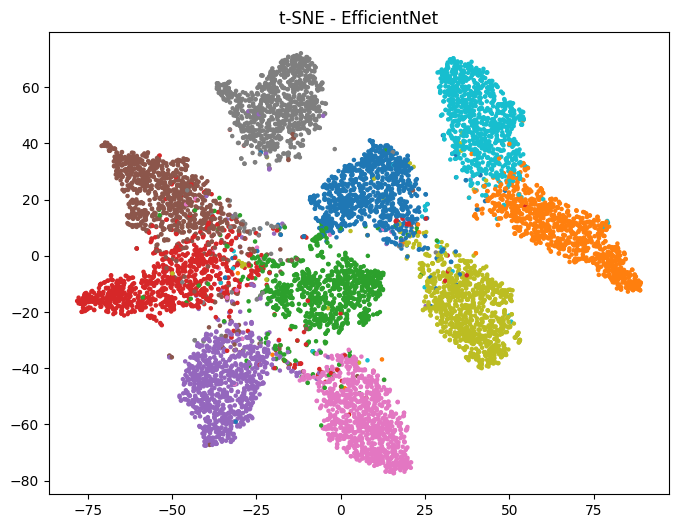

In [20]:
def extract_features_efficientnet(model, loader):
    model.eval()
    features = []
    labels_list = []

    with torch.no_grad():
        for images, labels in loader:
            images = images.to(device)

            x = model.features(images)
            x = model.avgpool(x)
            x = torch.flatten(x, 1)

            features.append(x.cpu())
            labels_list.extend(labels.numpy())

    features = torch.cat(features).numpy()
    return features, np.array(labels_list)

from sklearn.manifold import TSNE

features, labels = extract_features_efficientnet(efficientnet, test_loader)

tsne = TSNE(n_components=2, perplexity=30)
features_2d = tsne.fit_transform(features)

plt.figure(figsize=(8,6))
plt.scatter(features_2d[:,0], features_2d[:,1], c=labels, cmap='tab10', s=5)
plt.title("t-SNE - EfficientNet")

## **Dataset 1 Imbalanced:**

Same CIFAR dataset but making it imbalanced by reducing training samples but keeping the test samples same because it allows proper comparison

Changing the dataset will change many variables which will distrub comparison

In [22]:
imbalanced_train_dataset = torchvision.datasets.CIFAR10(
    root='./data',
    train=True,
    download=False,
    transform=transform
)

In [23]:
class_counts = {
    0: 5000,
    1: 4000,
    2: 3000,
    3: 2000,
    4: 1000,
    5: 800,
    6: 600,
    7: 400,
    8: 200,
    9: 100
}

In [24]:
targets = np.array(imbalanced_train_dataset.targets)

selected_indices = []

for cls, max_count in class_counts.items():
    cls_indices = np.where(targets == cls)[0]
    selected_indices.extend(cls_indices[:max_count])

selected_indices = np.array(selected_indices)

In [25]:
from torch.utils.data import Subset

imbalanced_subset = Subset(imbalanced_train_dataset, selected_indices)

imbalanced_loader = DataLoader(
    imbalanced_subset,
    batch_size=64,
    shuffle=True
)

In [26]:
from collections import Counter

subset_targets = targets[selected_indices]
print(Counter(subset_targets))

Counter({np.int64(0): 5000, np.int64(1): 4000, np.int64(2): 3000, np.int64(3): 2000, np.int64(4): 1000, np.int64(5): 800, np.int64(6): 600, np.int64(7): 400, np.int64(8): 200, np.int64(9): 100})


In [27]:
# ResNet + Imbalanced dataset + No class weighting
import torchvision.models as models
import torch.nn as nn

resnet_imb = models.resnet18(weights="IMAGENET1K_V1")
resnet_imb.fc = nn.Linear(resnet_imb.fc.in_features, 10)
resnet_imb = resnet_imb.to(device)

In [28]:
import torch.optim as optim

optimizer = optim.AdamW(resnet_imb.parameters(), lr=0.0005)
criterion = nn.CrossEntropyLoss()

In [29]:
def train_model(model, loader, criterion, optimizer, epochs=5):
    model.train()
    for epoch in range(epochs):
        running_loss = 0.0
        for images, labels in loader:
            images, labels = images.to(device), labels.to(device)

            optimizer.zero_grad()
            outputs = model(images)
            loss = criterion(outputs, labels)
            loss.backward()
            optimizer.step()

            running_loss += loss.item()

        print(f"Epoch [{epoch+1}/{epochs}], Loss: {running_loss/len(loader):.4f}")

train_model(resnet_imb, imbalanced_loader, criterion, optimizer, epochs=5)

Epoch [1/5], Loss: 0.4668
Epoch [2/5], Loss: 0.2324
Epoch [3/5], Loss: 0.1479
Epoch [4/5], Loss: 0.1076
Epoch [5/5], Loss: 0.0910


In [34]:
results["ResNet_imb No Weights"] = evaluate_model(resnet_imb, test_loader)

In [37]:
print("ResNet_imb No Weights")
for k,v in results["ResNet_imb No Weights"].items():
    print(k,":",v)

ResNet_imb No Weights
Top1 : 0.7959
Top3 : 0.9632
Macro Precision : 0.8367666383349727
Macro Recall : 0.7959
Macro F1 : 0.7982335019040401


In [38]:
# ResNet + Imbalanced + Weights
counts = np.array([class_counts[i] for i in range(10)])

weights = 1.0 / counts
weights = weights / weights.sum() * 10

class_weights = torch.tensor(weights, dtype=torch.float).to(device)

In [39]:
criterion_weighted = nn.CrossEntropyLoss(weight=class_weights)

In [40]:
resnet_imb_w = models.resnet18(weights="IMAGENET1K_V1")
resnet_imb_w.fc = nn.Linear(resnet_imb_w.fc.in_features, 10)
resnet_imb_w = resnet_imb_w.to(device)

optimizer = optim.AdamW(resnet_imb_w.parameters(), lr=0.0005)

train_model(resnet_imb_w, imbalanced_loader, criterion_weighted, optimizer, epochs=5)

Epoch [1/5], Loss: 0.9035
Epoch [2/5], Loss: 0.4780
Epoch [3/5], Loss: 0.3234
Epoch [4/5], Loss: 0.3815
Epoch [5/5], Loss: 0.1273


In [41]:
results["ResNet_imb with Weights"] = evaluate_model(resnet_imb_w, test_loader)

print("ResNet_imb with Weights")
for k,v in results["ResNet_imb with Weights"].items():
    print(k,":",v)

ResNet_imb with Weights
Top1 : 0.8104
Top3 : 0.9654
Macro Precision : 0.8444623210366846
Macro Recall : 0.8104000000000001
Macro F1 : 0.8094686841692627


In [42]:
# EfficientNet + Imbalanced + No Weights
from torchvision.models import efficientnet_b0

efficient_imb = efficientnet_b0(weights="IMAGENET1K_V1")
efficient_imb.classifier[1] = nn.Linear(efficient_imb.classifier[1].in_features, 10)
efficient_imb = efficient_imb.to(device)

In [43]:
optimizer = optim.AdamW(efficient_imb.parameters(), lr=0.0005)
criterion = nn.CrossEntropyLoss()

train_model(efficient_imb, imbalanced_loader, criterion, optimizer, epochs=5)

Epoch [1/5], Loss: 0.4004
Epoch [2/5], Loss: 0.1565
Epoch [3/5], Loss: 0.1010
Epoch [4/5], Loss: 0.0712
Epoch [5/5], Loss: 0.0521


In [45]:
results["EfficientNet_imb no Weights"] = evaluate_model(efficient_imb, test_loader)

print("EfficientNet_imb no Weights")
for k,v in results["EfficientNet_imb no Weights"].items():
    print(k,":",v)

EfficientNet_imb no Weights
Top1 : 0.8967
Top3 : 0.985
Macro Precision : 0.9058894684162146
Macro Recall : 0.8966999999999998
Macro F1 : 0.8967351125287836


In [46]:
# Efficient + weights
efficient_imb_w = efficientnet_b0(weights="IMAGENET1K_V1")
efficient_imb_w.classifier[1] = nn.Linear(efficient_imb_w.classifier[1].in_features, 10)
efficient_imb_w = efficient_imb_w.to(device)

In [47]:
optimizer = optim.AdamW(efficient_imb_w.parameters(), lr=0.0005)
criterion_weighted = nn.CrossEntropyLoss(weight=class_weights)

In [48]:
train_model(efficient_imb_w, imbalanced_loader, criterion_weighted, optimizer, epochs=5)

Epoch [1/5], Loss: 0.6659
Epoch [2/5], Loss: 0.2764
Epoch [3/5], Loss: 0.1679
Epoch [4/5], Loss: 0.1558
Epoch [5/5], Loss: 0.0905


In [49]:
results["EfficientNet_imb with Weights"] = evaluate_model(efficient_imb_w, test_loader)

print("EfficientNet_imb with Weights")
for k,v in results["EfficientNet_imb with Weights"].items():
    print(k,":",v)

EfficientNet_imb with Weights
Top1 : 0.9091
Top3 : 0.9895
Macro Precision : 0.9110965260114356
Macro Recall : 0.9090999999999999
Macro F1 : 0.9093004281076537


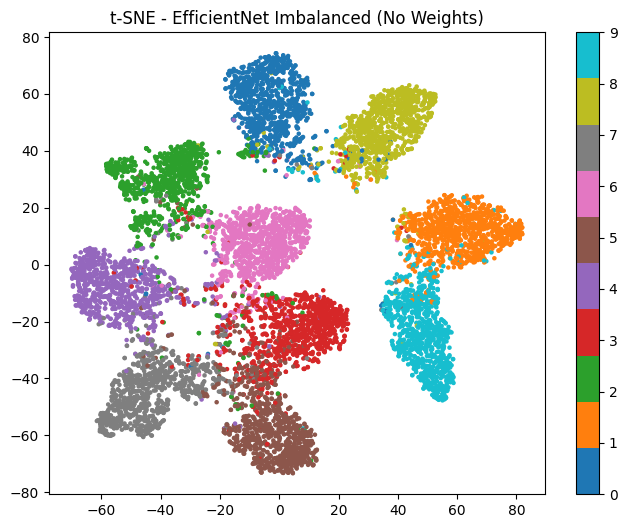

In [50]:
features_no_w, labels_no_w = extract_features_efficientnet(
    efficient_imb, test_loader
)

# t-SNE
tsne = TSNE(n_components=2, perplexity=30, random_state=42)
features_2d_no_w = tsne.fit_transform(features_no_w)

# Plot
plt.figure(figsize=(8,6))
plt.scatter(features_2d_no_w[:,0], features_2d_no_w[:,1],
            c=labels_no_w, cmap='tab10', s=5)
plt.title("t-SNE - EfficientNet Imbalanced (No Weights)")
plt.colorbar()
plt.show()

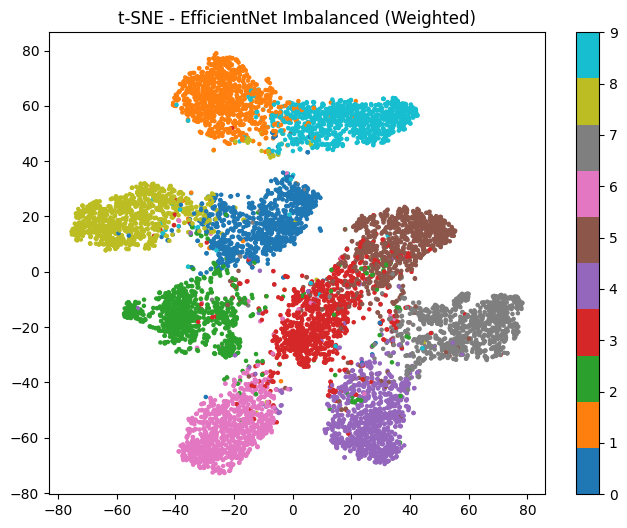

In [51]:
features_w, labels_w = extract_features_efficientnet(
    efficient_imb_w, test_loader
)

# t-SNE
tsne = TSNE(n_components=2, perplexity=30, random_state=42)
features_2d_w = tsne.fit_transform(features_w)

# Plot
plt.figure(figsize=(8,6))
plt.scatter(features_2d_w[:,0], features_2d_w[:,1],
            c=labels_w, cmap='tab10', s=5)
plt.title("t-SNE - EfficientNet Imbalanced (Weighted)")
plt.colorbar()
plt.show()